In [1]:
import hoda
import tensorly as tl
%pip install toeplitzlda
print(tl.get_backend())
%pip freeze | grep moabb


[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
cupy
moabb==1.0.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
datasets = [
       #BI2012(),
       #BI2014a(),
       #BI2014b(),
       #BI2015a(),
       #BI2015b(),
       BNCI2014008(),
       #BNCI2014009(),
       #BNCI2015_003(),
       #Cattan2019_VR(),
       #EPFLP300(),
       #Huebner2017(),
       #Huebner2018(),
       #Lee2019_ERP(),
       #Sosulski2019()   
   ]



<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
BNCI2014008 has been renamed to BNCI2014_008. BNCI2014008 will be removed in version 1.1.
The dataset class name 'BNCI2014008' must be an abb

To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
from sklearn.pipeline import Pipeline
from mne.decoding import Scaler
from hoda.hoda import  HODA, GreedyBTTDA, InfoBTTDA
from hoda.classification import Vectorize,ToeplitzLDAWrapper
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, GridSearchCV


hoda_params = dict(
    max_iter=128,
    tol=1e-12,
    init ='random',
    shrinkage='lw',
    toeplitz=None,
    obj='tr',
    solver='lanczos',
    taper=False,
    extra_train_info=False,
    verbose=False,    
)



scaler = Scaler(scalings='mean', with_mean=True)

In [4]:
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import dask
from sklearn.base import clone

import dask.dataframe as dd
%env PYTHONWARNINGS=ignore

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

df = []

@dask.delayed
def evaluate_fold(X,y, train_idc, test_idc, fold):
    bttda = Pipeline([
        ('bttda', InfoBTTDA(
                max_blocks=16,
                info_crit='bic',
                hoda_params=hoda_params,
                verbose=True,
                extra_train_info=False,
        )),
        ('vec', Vectorize()),
        ('lda', LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))        
    ])   

    """
    hoda = Pipeline([
        ('hoda', GreedyBTTDA(
                max_blocks=1,
                hoda_params=hoda_params,
                verbose=True,
                extra_train_info=False,
                gs_params=dict(n_jobs=-1),
        )),
        ('vec', Vectorize()),
        ('lda', LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))        
    ])   
    """
    
    tlda = ToeplitzLDAWrapper()
    
    bttda.fit(X[train_idc],y[train_idc], bttda__X_test=X[test_idc], bttda__y_test=y[test_idc])
    tlda.fit(X[train_idc], y[train_idc])
    #hoda.fit(X[train_idc], y[train_idc])

    df_fold = bttda['bttda'].train_info_
    train_score = []
    test_score=[]
    for n_blocks in range(1,bttda['bttda'].n_blocks_+1):
        Xt  = bttda['bttda'].transform(X, n_blocks=n_blocks)
        bttda[1:].fit(Xt[train_idc], y[train_idc])
        train_score.append(roc_auc_score(y[train_idc], bttda[1:].decision_function(Xt[train_idc])))
        test_score.append(roc_auc_score(y[test_idc], bttda[1:].decision_function(Xt[test_idc])))
    df_fold['bttda_train_score'] = train_score
    df_fold['bttda_test_score'] = test_score
    df_fold['tlda_train_score'] = roc_auc_score(y[train_idc], tlda.decision_function(X[train_idc])) 
    df_fold['tlda_test_score'] = roc_auc_score(y[test_idc], tlda.decision_function(X[test_idc])) 
    #df_fold['hoda_train_score'] = roc_auc_score(y[train_idc], hoda.decision_function(X[train_idc])) 
    #df_fold['hoda_test_score'] = roc_auc_score(y[test_idc], hoda.decision_function(X[test_idc])) 
    df_fold['dataset'] = dataset.code
    df_fold['subject'] = session[0]
    df_fold['session'] = session[1]
    df_fold['fold']=fold
    return df_fold


df = []
for dataset in datasets:
    X_sub, y_sub, meta = paradigm.get_data(dataset, 
        subjects=[4]
    )
    idc = meta.reset_index()\
        .groupby(['subject', 'session'])\
        .index.aggregate(list)
    
    for session, session_idc in idc.items():
        print(dataset.code + ' ' + str(session))
        session_idc = np.array(session_idc) 

        
        X =X_sub[session_idc]
        y = y_sub[session_idc]
        
        X = tl.tensor(X)

        for fold, (train_idc, test_idc) in enumerate(cv.split(X,y)):        
            df_fold = evaluate_fold (X,y, train_idc, test_idc, fold)
            df.append(df_fold)

df = dask.compute(df)
df = pd.concat([pd.DataFrame(d) for d in df[0]], axis=0)

/tmp/ipykernel_1535/2677531415.py:8: DeprecationWarning: The current Dask DataFrame implementation is deprecated. 
In a future release, Dask DataFrame will use new implementation that
contains several improvements including a logical query planning.
The user-facing DataFrame API will remain unchanged.

The new implementation is already available and can be enabled by
installing the dask-expr library:

    $ pip install dask-expr

and turning the query planning option on:

    >>> import dask
    >>> dask.config.set({'dataframe.query-planning': True})
    >>> import dask.dataframe as dd

API documentation for the new implementation is available at
https://docs.dask.org/en/stable/dask-expr-api.html

Any feedback can be reported on the Dask issue tracker
https://github.com/dask/dask/issues 

  import dask.dataframe as dd


env: PYTHONWARNINGS=ignore


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


BNCI2014-008 (4, '0')
Fitting block 1/16...
Fitting block 1/16...
Fitting block 1/16...
Fitting block 1/16...
Fitting block 1/16...
Fitting block 2/16...
Fitting block 2/16...
Fitting block 2/16...
Fitting block 2/16...
Fitting block 2/16...
Fitting block 3/16...
Fitting block 3/16...
Fitting block 3/16...
Fitting block 3/16...
Fitting block 3/16...
Fitting block 4/16...
Fitting block 4/16...
Fitting block 4/16...
Fitting block 4/16...
Fitting block 4/16...
Fitting block 5/16...
Fitting block 5/16...
Fitting block 5/16...
Fitting block 5/16...
Fitting block 5/16...
Fitting block 6/16...
Fitting block 7/16...
Fitting block 6/16...
Fitting block 6/16...
Fitting block 6/16...
Fitting block 7/16...
Fitting block 7/16...
Fitting block 8/16...
Fitting block 7/16...
Fitting block 8/16...
Fitting block 6/16...
Fitting block 9/16...
Fitting block 8/16...
Fitting block 9/16...
Fitting block 8/16...
Fitting block 9/16...
Fitting block 10/16...
Fitting block 10/16...
Fitting block 9/16...
Fitting 

In [5]:
pd.set_option("display.max_rows", None)
df

,block,rank,bic,bttda_train_score,bttda_test_score,tlda_train_score,tlda_test_score,dataset,subject,session,fold
0,1,"(1, 1)",5585.066722,0.816172,0.826908,0.845723,0.830480,BNCI2014-008,4,0,0
1,2,"(1, 1)",5586.623173,0.816043,0.825000,0.845723,0.830480,BNCI2014-008,4,0,0
2,3,"(1, 1)",5571.715742,0.816406,0.824296,0.845723,0.830480,BNCI2014-008,4,0,0
3,4,"(1, 1)",5588.065347,0.816465,0.824112,0.845723,0.830480,BNCI2014-008,4,0,0
4,5,"(1, 1)",5271.218466,0.829529,0.822061,0.845723,0.830480,BNCI2014-008,4,0,0
5,6,"(1, 1)",5338.217187,0.837378,0.823367,0.845723,0.830480,BNCI2014-008,4,0,0
6,7,"(1, 1)",5324.600820,0.837519,0.822939,0.845723,0.830480,BNCI2014-008,4,0,0
7,8,"(1, 1)",5310.645305,0.837674,0.822745,0.845723,0.830480,BNCI2014-008,4,0,0
8,9,"(1, 1)",5307.980428,0.837698,0.822735,0.845723,0.830480,BNCI2014-008,4,0,0
9,10,"(1, 1)",5277.483862,0.837727,0.822694,0.845723,0.830480,BNCI2014-008,4,0,0


In [6]:
df_diff = df.reset_index()
idx = ['dataset', 'subject', 'session', 'fold']
df_diff = df_diff.set_index(idx)

df_first = df_diff.groupby(['dataset', 'subject', 'session', 'fold']).tlda_test_score.aggregate('first')
df_diff['test_score_diff_tlda'] = df_diff['bttda_test_score'] - df_first

#df_first = df_diff.groupby(['dataset', 'subject', 'session', 'fold']).hoda_test_score.aggregate('first')
#df_diff['test_score_diff_hoda'] = df_diff['bttda_test_score'] - df_first
df_diff = df_diff.reset_index()
df_diff

,dataset,subject,session,fold,index,block,rank,bic,bttda_train_score,bttda_test_score,tlda_train_score,tlda_test_score,test_score_diff_tlda
0,BNCI2014-008,4,0,0,0,1,"(1, 1)",5585.066722,0.816172,0.826908,0.845723,0.830480,-0.003571
1,BNCI2014-008,4,0,0,1,2,"(1, 1)",5586.623173,0.816043,0.825000,0.845723,0.830480,-0.005480
2,BNCI2014-008,4,0,0,2,3,"(1, 1)",5571.715742,0.816406,0.824296,0.845723,0.830480,-0.006184
3,BNCI2014-008,4,0,0,3,4,"(1, 1)",5588.065347,0.816465,0.824112,0.845723,0.830480,-0.006367
4,BNCI2014-008,4,0,0,4,5,"(1, 1)",5271.218466,0.829529,0.822061,0.845723,0.830480,-0.008418
5,BNCI2014-008,4,0,0,5,6,"(1, 1)",5338.217187,0.837378,0.823367,0.845723,0.830480,-0.007112
6,BNCI2014-008,4,0,0,6,7,"(1, 1)",5324.600820,0.837519,0.822939,0.845723,0.830480,-0.007541
7,BNCI2014-008,4,0,0,7,8,"(1, 1)",5310.645305,0.837674,0.822745,0.845723,0.830480,-0.007735
8,BNCI2014-008,4,0,0,8,9,"(1, 1)",5307.980428,0.837698,0.822735,0.845723,0.830480,-0.007745
9,BNCI2014-008,4,0,0,9,10,"(1, 1)",5277.483862,0.837727,0.822694,0.845723,0.830480,-0.007786


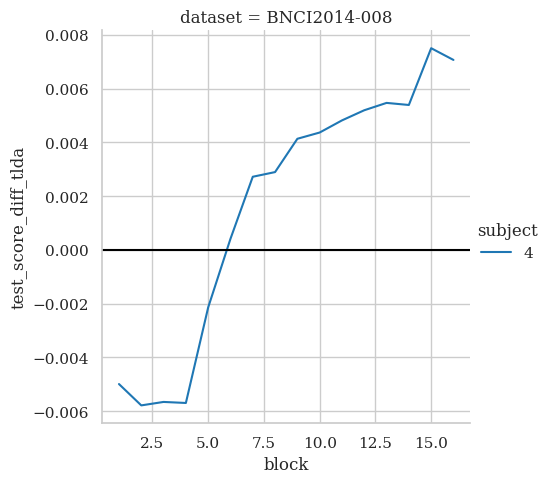

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.relplot(
    data=df_diff,
    col='dataset',
    #col_wrap=4,
    x='block',
    y='test_score_diff_tlda',
    hue='subject',
    kind="line",
    palette="tab10",
    ci=None,
    #units='fold',
    #estimator=None,
)
plt.axhline(0, color='black')
plt.show()

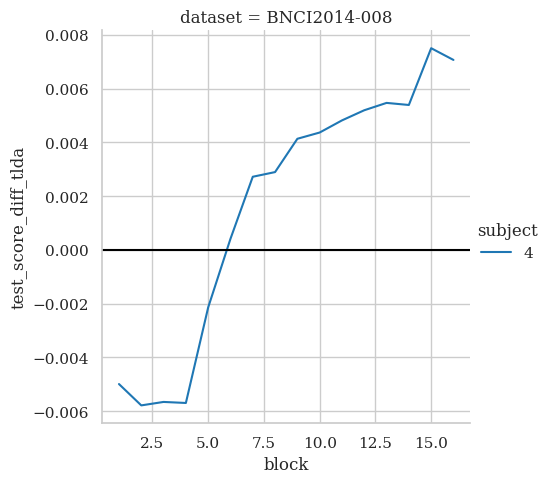

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.relplot(
    data=df_diff,
    col='dataset',
    #col_wrap=4,
    x='block',
    y='test_score_diff_tlda',
    hue='subject',
    kind="line",
    palette="tab10",
    ci=None,
    #units='fold',
    #estimator=None,
)
plt.axhline(0, color='black')
plt.show()

In [9]:
sns.relplot(
    data=df_diff,
    col='dataset',
    #col_wrap=4,
    x='block',
    y='aicc',
    hue='fold',
    kind="line",
    palette="tab10",
    ci=None,
    #units='fold',
    #estimator=None,
)
_=plt.show()

ValueError: Could not interpret value `aicc` for parameter `y`